In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = r"../data/processed_cicids2017.csv"

labels = pd.read_csv(
    DATA_PATH,
    usecols=["Attack_Type"]
)

print("Total flows:", len(labels))
print("\nClass distribution:")
print(labels["Attack_Type"].value_counts())

Total flows: 2827876

Class distribution:
Attack_Type
BENIGN          2271320
DOS              251712
PORTSCAN         158804
DDOS             128025
BRUTE_FORCE       13832
WEB_ATTACK         2180
BOT                1956
INFILTRATION         36
HEARTBLEED           11
Name: count, dtype: int64


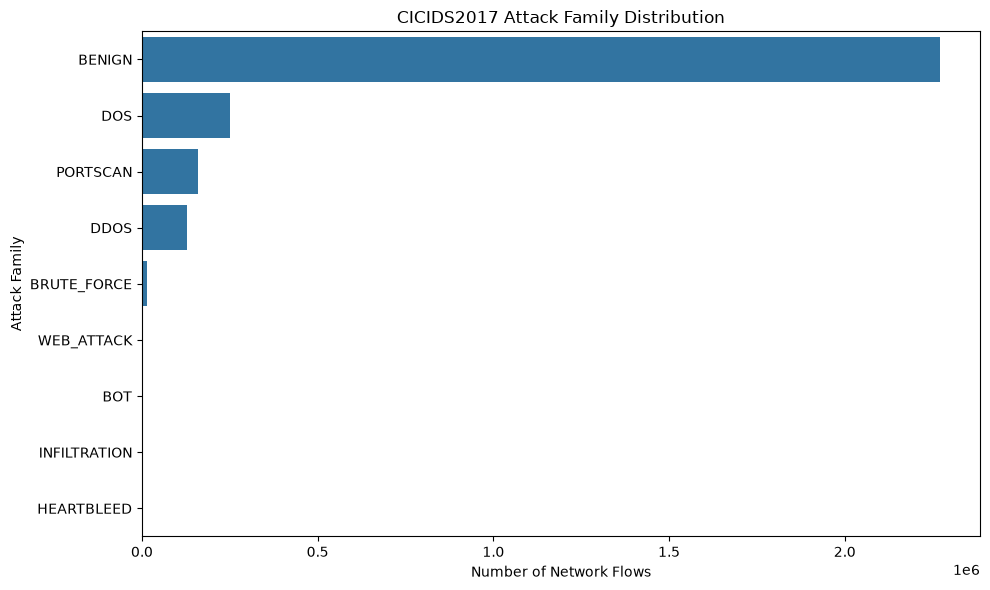

In [2]:
plt.figure(figsize=(10, 6))

class_counts = labels["Attack_Type"].value_counts()

sns.barplot(
    x=class_counts.values,
    y=class_counts.index
)

plt.title("CICIDS2017 Attack Family Distribution")
plt.xlabel("Number of Network Flows")
plt.ylabel("Attack Family")
plt.tight_layout()

plt.savefig(
    "../results/graphs/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Class distribution (%):
Attack_Type
BENIGN          80.3189
DOS              8.9011
PORTSCAN         5.6157
DDOS             4.5272
BRUTE_FORCE      0.4891
WEB_ATTACK       0.0771
BOT              0.0692
INFILTRATION     0.0013
HEARTBLEED       0.0004
Name: proportion, dtype: float64


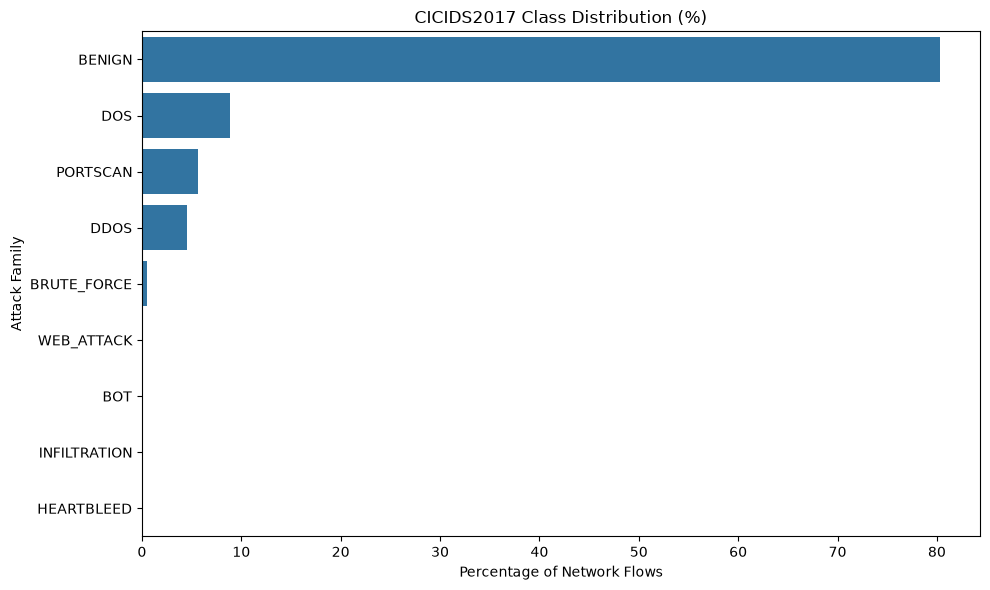

In [3]:
class_percent = (
    labels["Attack_Type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(4)
)

print("Class distribution (%):")
print(class_percent)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=class_percent.values,
    y=class_percent.index
)

plt.title("CICIDS2017 Class Distribution (%)")
plt.xlabel("Percentage of Network Flows")
plt.ylabel("Attack Family")
plt.tight_layout()

plt.savefig(
    "../results/graphs/class_distribution_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [4]:
import numpy as np

missing_counts = pd.Series(dtype="int64")
infinite_counts = pd.Series(dtype="int64")

for chunk in pd.read_csv(DATA_PATH, chunksize=100000):
    numeric_chunk = chunk.select_dtypes(include=np.number)

    chunk_missing = numeric_chunk.isna().sum()
    chunk_infinite = np.isinf(numeric_chunk).sum()

    missing_counts = missing_counts.add(chunk_missing, fill_value=0)
    infinite_counts = infinite_counts.add(chunk_infinite, fill_value=0)

print("Total missing values:", int(missing_counts.sum()))
print("Total infinite values:", int(infinite_counts.sum()))

print("\nColumns with missing values:")
print(missing_counts[missing_counts > 0])

print("\nColumns with infinite values:")
print(infinite_counts[infinite_counts > 0])

Total missing values: 0
Total infinite values: 0

Columns with missing values:
Series([], dtype: float64)

Columns with infinite values:
Series([], dtype: float64)


In [5]:
dtypes = pd.read_csv(
    DATA_PATH,
    nrows=1000
).dtypes

print("Data types:")
print(dtypes.value_counts())

print("\nNon-numeric columns:")
print(dtypes[dtypes == "object"])

Data types:
int64      54
float64    24
str         1
Name: count, dtype: int64

Non-numeric columns:
Series([], dtype: object)


In [6]:
import numpy as np

feature_values = {}

for chunk in pd.read_csv(DATA_PATH, chunksize=100000):
    numeric_chunk = chunk.drop(columns=["Attack_Type"])

    for column in numeric_chunk.columns:
        if column not in feature_values:
            feature_values[column] = set()

        # Keep only unique values found in this chunk
        feature_values[column].update(
            numeric_chunk[column].dropna().unique().tolist()
        )

constant_features = [
    column for column, values in feature_values.items()
    if len(values) <= 1
]

print("Total network features:", len(feature_values))
print("Constant features:", len(constant_features))

if constant_features:
    print("\nConstant features:")
    for feature in constant_features:
        print("-", feature)
else:
    print("\nNo constant features found.")

Total network features: 78
Constant features: 8

Constant features:
- Bwd PSH Flags
- Bwd URG Flags
- Fwd Avg Bytes/Bulk
- Fwd Avg Packets/Bulk
- Fwd Avg Bulk Rate
- Bwd Avg Bytes/Bulk
- Bwd Avg Packets/Bulk
- Bwd Avg Bulk Rate


In [7]:
constant_features = [
    "Bwd PSH Flags",
    "Bwd URG Flags",
    "Fwd Avg Bytes/Bulk",
    "Fwd Avg Packets/Bulk",
    "Fwd Avg Bulk Rate",
    "Bwd Avg Bytes/Bulk",
    "Bwd Avg Packets/Bulk",
    "Bwd Avg Bulk Rate"
]

correlation_data = []

for chunk in pd.read_csv(DATA_PATH, chunksize=100000):
    features = chunk.drop(columns=["Attack_Type"] + constant_features)
    correlation_data.append(features)

corr_sample = pd.concat(correlation_data, ignore_index=True)

print("Feature matrix shape for correlation:", corr_sample.shape)

corr_matrix = corr_sample.corr()

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        correlation = corr_matrix.iloc[i, j]

        if abs(correlation) > 0.95:
            high_corr_pairs.append(
                (
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    correlation
                )
            )

print("\nHighly correlated feature pairs (|correlation| > 0.95):")
print("Number of pairs:", len(high_corr_pairs))

for feature1, feature2, correlation in high_corr_pairs[:30]:
    print(
        f"{feature1} <-> {feature2}: {correlation:.4f}"
    )

Feature matrix shape for correlation: (2827876, 70)

Highly correlated feature pairs (|correlation| > 0.95):
Number of pairs: 39
Flow Duration <-> Fwd IAT Total: 0.9986
Total Fwd Packets <-> Total Backward Packets: 0.9991
Total Fwd Packets <-> Total Length of Bwd Packets: 0.9970
Total Fwd Packets <-> Subflow Fwd Packets: 1.0000
Total Fwd Packets <-> Subflow Bwd Packets: 0.9991
Total Fwd Packets <-> Subflow Bwd Bytes: 0.9970
Total Backward Packets <-> Total Length of Bwd Packets: 0.9944
Total Backward Packets <-> Subflow Fwd Packets: 0.9991
Total Backward Packets <-> Subflow Bwd Packets: 1.0000
Total Backward Packets <-> Subflow Bwd Bytes: 0.9944
Total Length of Fwd Packets <-> Subflow Fwd Bytes: 1.0000
Total Length of Bwd Packets <-> Subflow Fwd Packets: 0.9970
Total Length of Bwd Packets <-> Subflow Bwd Packets: 0.9944
Total Length of Bwd Packets <-> Subflow Bwd Bytes: 1.0000
Fwd Packet Length Max <-> Fwd Packet Length Std: 0.9684
Fwd Packet Length Mean <-> Avg Fwd Segment Size: 1.000

In [8]:
correlation_report = pd.DataFrame(
    high_corr_pairs,
    columns=["Feature_1", "Feature_2", "Correlation"]
)

correlation_report = correlation_report.sort_values(
    by="Correlation",
    key=lambda x: x.abs(),
    ascending=False
)

correlation_report.to_csv(
    "../results/reports/highly_correlated_features.csv",
    index=False
)

print("Saved correlation report.")
print("Number of highly correlated pairs:", len(correlation_report))
print("\nTop 15 pairs:")
print(correlation_report.head(15).to_string(index=False))

Saved correlation report.
Number of highly correlated pairs: 39

Top 15 pairs:
                  Feature_1              Feature_2  Correlation
          Total Fwd Packets    Subflow Fwd Packets     1.000000
     Fwd Packet Length Mean   Avg Fwd Segment Size     1.000000
              Fwd PSH Flags         SYN Flag Count     1.000000
              Fwd URG Flags         CWE Flag Count     1.000000
          Fwd Header Length    Fwd Header Length.1     1.000000
     Total Backward Packets    Subflow Bwd Packets     1.000000
     Bwd Packet Length Mean   Avg Bwd Segment Size     1.000000
Total Length of Bwd Packets      Subflow Bwd Bytes     1.000000
Total Length of Fwd Packets      Subflow Fwd Bytes     0.999999
        Subflow Fwd Packets    Subflow Bwd Packets     0.999070
          Total Fwd Packets    Subflow Bwd Packets     0.999070
          Total Fwd Packets Total Backward Packets     0.999070
     Total Backward Packets    Subflow Fwd Packets     0.999070
              Flow Durati

In [9]:
numeric_features = pd.read_csv(
    DATA_PATH,
    nrows=10000
).drop(columns=["Attack_Type"])

summary = numeric_features.describe().T

summary["range"] = summary["max"] - summary["min"]

extreme_features = summary.sort_values(
    by="range",
    ascending=False
)

print("Top 15 features by value range:")
print(
    extreme_features[
        ["min", "max", "mean", "std", "range"]
    ].head(15).to_string()
)

Top 15 features by value range:
               min           max          mean           std         range
Flow Bytes/s   0.0  2.070000e+09  1.734747e+06  3.113420e+07  2.070000e+09
Bwd IAT Total  0.0  1.200000e+08  1.114226e+07  3.038014e+07  1.200000e+08
Idle Mean      0.0  1.200000e+08  3.557695e+06  1.246362e+07  1.200000e+08
Idle Max       0.0  1.200000e+08  3.689130e+06  1.284399e+07  1.200000e+08
Idle Min       0.0  1.200000e+08  3.382299e+06  1.226320e+07  1.200000e+08
Bwd IAT Mean   0.0  1.200000e+08  1.593378e+06  8.287300e+06  1.200000e+08
Fwd IAT Max    0.0  1.200000e+08  4.007973e+06  1.310720e+07  1.200000e+08
Fwd IAT Min    0.0  1.200000e+08  7.904814e+05  7.605525e+06  1.200000e+08
Fwd IAT Mean   0.0  1.200000e+08  1.543387e+06  7.873753e+06  1.200000e+08
Bwd IAT Max    0.0  1.200000e+08  3.573130e+06  1.272248e+07  1.200000e+08
Bwd IAT Min    0.0  1.200000e+08  9.318542e+05  8.009963e+06  1.200000e+08
Fwd IAT Total  0.0  1.200000e+08  1.163904e+07  3.083129e+07  1.2000

In [10]:
# Check skewness of numeric features

numeric_features = pd.read_csv(
    DATA_PATH,
    nrows=10000
).drop(columns=["Attack_Type"])

skewness = numeric_features.skew().sort_values(
    ascending=False
)

print("Top 15 positively skewed features:")
print(skewness.head(15).to_string())

print("\nTop 15 negatively skewed features:")
print(skewness.tail(15).to_string())

Top 15 positively skewed features:
ECE Flag Count                 100.000000
RST Flag Count                 100.000000
Active Min                      64.506720
Active Mean                     60.735777
Flow Bytes/s                    44.164724
Fwd Header Length.1             35.944743
Fwd Header Length               35.944743
Subflow Fwd Packets             35.539546
Total Fwd Packets               35.539546
Total Length of Bwd Packets     34.887800
Subflow Bwd Bytes               34.887800
Active Max                      34.342579
Flow IAT Min                    33.097765
Total Backward Packets          30.431687
Subflow Bwd Packets             30.431687

Top 15 negatively skewed features:
Fwd Packet Length Min    1.039177
ACK Flag Count           1.012458
Min Packet Length        0.862171
min_seg_size_forward     0.562509
Bwd PSH Flags            0.000000
Fwd URG Flags            0.000000
Bwd URG Flags            0.000000
Fwd Avg Packets/Bulk     0.000000
Bwd Avg Bulk Rate        0.

In [11]:
# Identify features involved in very high correlations

high_corr_features = pd.concat([
    correlation_report["Feature_1"],
    correlation_report["Feature_2"]
]).value_counts()

print("Top 20 features involved in highly correlated pairs:")
print(high_corr_features.head(20).to_string())

Top 20 features involved in highly correlated pairs:
Total Fwd Packets              5
Total Backward Packets         5
Total Length of Bwd Packets    5
Subflow Fwd Packets            5
Subflow Bwd Packets            5
Subflow Bwd Bytes              5
Flow IAT Max                   4
Idle Mean                      4
Idle Max                       4
Fwd IAT Max                    3
Bwd Packet Length Max          3
Idle Min                       3
Bwd Packet Length Mean         2
Avg Bwd Segment Size           2
Fwd Packet Length Mean         1
Fwd PSH Flags                  1
Fwd URG Flags                  1
Fwd Header Length              1
Total Length of Fwd Packets    1
Flow Duration                  1


In [12]:
# Compare important numeric features across attack families

selected_features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s"
]

comparison = pd.read_csv(
    DATA_PATH,
    usecols=["Attack_Type"] + selected_features
)

print("Mean values by attack family:")
print(
    comparison.groupby("Attack_Type")[selected_features]
    .mean()
    .round(2)
    .to_string()
)

Mean values by attack family:
              Flow Duration  Total Fwd Packets  Total Backward Packets  Total Length of Fwd Packets  Total Length of Bwd Packets  Flow Bytes/s  Flow Packets/s
Attack_Type                                                                                                                                                   
BENIGN         1.122960e+07              10.66                   12.15                       636.03                     18863.45    1779841.56        64778.59
BOT            3.527369e+05               3.21                    3.36                      2658.94                        64.10     307099.15        46841.28
BRUTE_FORCE    5.220108e+06               7.90                   11.53                       464.44                       643.31     458816.16        73062.46
DDOS           1.695586e+07               4.47                    3.26                        31.91                      7373.74      61117.88          172.79
DOS            5

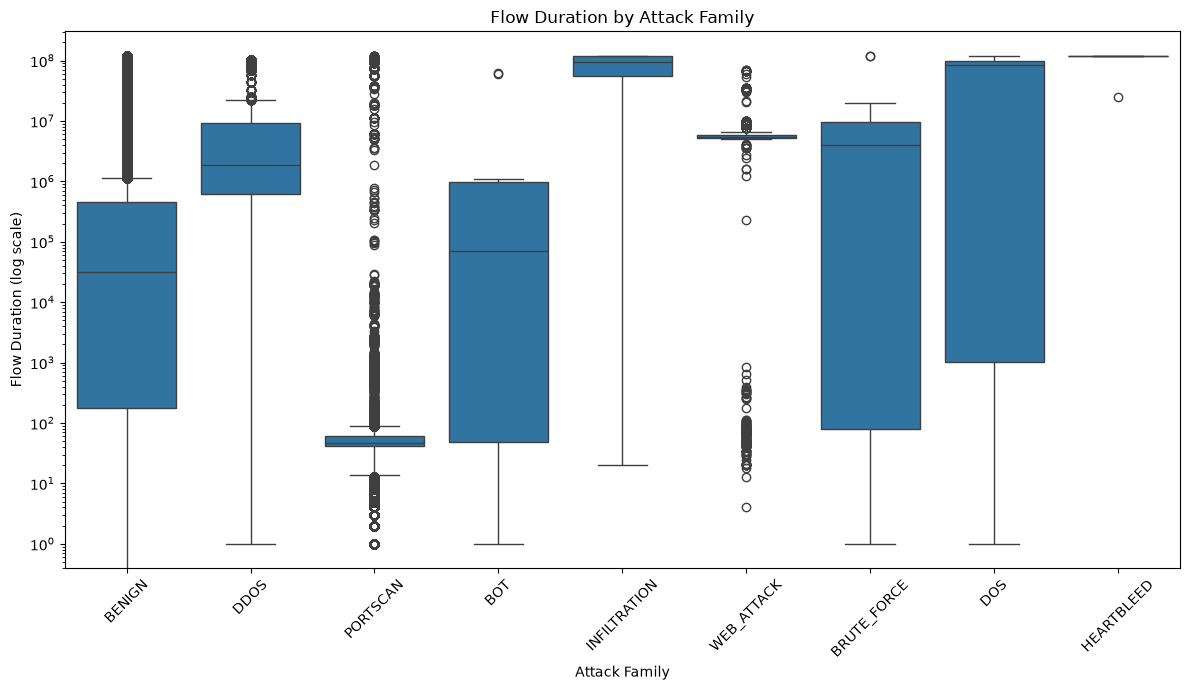

In [13]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=comparison,
    x="Attack_Type",
    y="Flow Duration"
)

plt.yscale("log")

plt.title("Flow Duration by Attack Family")
plt.xlabel("Attack Family")
plt.ylabel("Flow Duration (log scale)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../results/graphs/flow_duration_by_attack.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

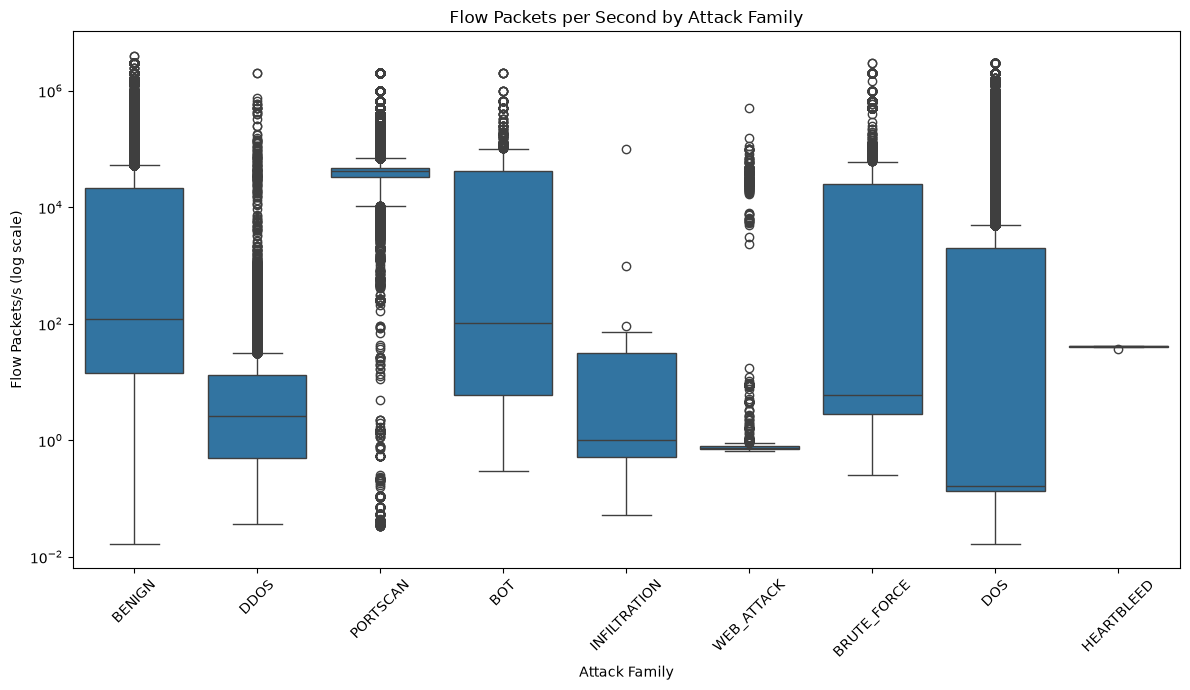

In [14]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=comparison,
    x="Attack_Type",
    y="Flow Packets/s"
)

plt.yscale("log")

plt.title("Flow Packets per Second by Attack Family")
plt.xlabel("Attack Family")
plt.ylabel("Flow Packets/s (log scale)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../results/graphs/flow_packets_per_second_by_attack.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
class_counts = labels["Attack_Type"].value_counts()

print("Class sample counts:")
print(class_counts.to_string())

print("\nClasses with fewer than 100 samples:")

rare_classes = class_counts[class_counts < 100]

if len(rare_classes) > 0:
    print(rare_classes.to_string())
else:
    print("No classes have fewer than 100 samples.")

Class sample counts:
Attack_Type
BENIGN          2271320
DOS              251712
PORTSCAN         158804
DDOS             128025
BRUTE_FORCE       13832
WEB_ATTACK         2180
BOT                1956
INFILTRATION         36
HEARTBLEED           11

Classes with fewer than 100 samples:
Attack_Type
INFILTRATION    36
HEARTBLEED      11


In [16]:
rare_class_report = (
    class_counts[class_counts < 100]
    .rename_axis("Attack_Type")
    .reset_index(name="Sample_Count")
)

rare_class_report["Percentage"] = (
    rare_class_report["Sample_Count"]
    / len(labels)
    * 100
).round(6)

print("Rare attack class report:")
print(rare_class_report.to_string(index=False))

rare_class_report.to_csv(
    "../results/reports/rare_attack_classes.csv",
    index=False
)

print("\nSaved:")
print("../results/reports/rare_attack_classes.csv")

Rare attack class report:
 Attack_Type  Sample_Count  Percentage
INFILTRATION            36    0.001273
  HEARTBLEED            11    0.000389

Saved:
../results/reports/rare_attack_classes.csv


In [17]:
class_distribution_report = (
    labels["Attack_Type"]
    .value_counts()
    .rename_axis("Attack_Type")
    .reset_index(name="Sample_Count")
)

class_distribution_report["Percentage"] = (
    class_distribution_report["Sample_Count"]
    / len(labels)
    * 100
).round(6)

print("Complete class distribution report:")
print(class_distribution_report.to_string(index=False))

class_distribution_report.to_csv(
    "../results/reports/class_distribution_report.csv",
    index=False
)

print("\nSaved:")
print("../results/reports/class_distribution_report.csv")

Complete class distribution report:
 Attack_Type  Sample_Count  Percentage
      BENIGN       2271320   80.318939
         DOS        251712    8.901098
    PORTSCAN        158804    5.615663
        DDOS        128025    4.527249
 BRUTE_FORCE         13832    0.489130
  WEB_ATTACK          2180    0.077090
         BOT          1956    0.069169
INFILTRATION            36    0.001273
  HEARTBLEED            11    0.000389

Saved:
../results/reports/class_distribution_report.csv


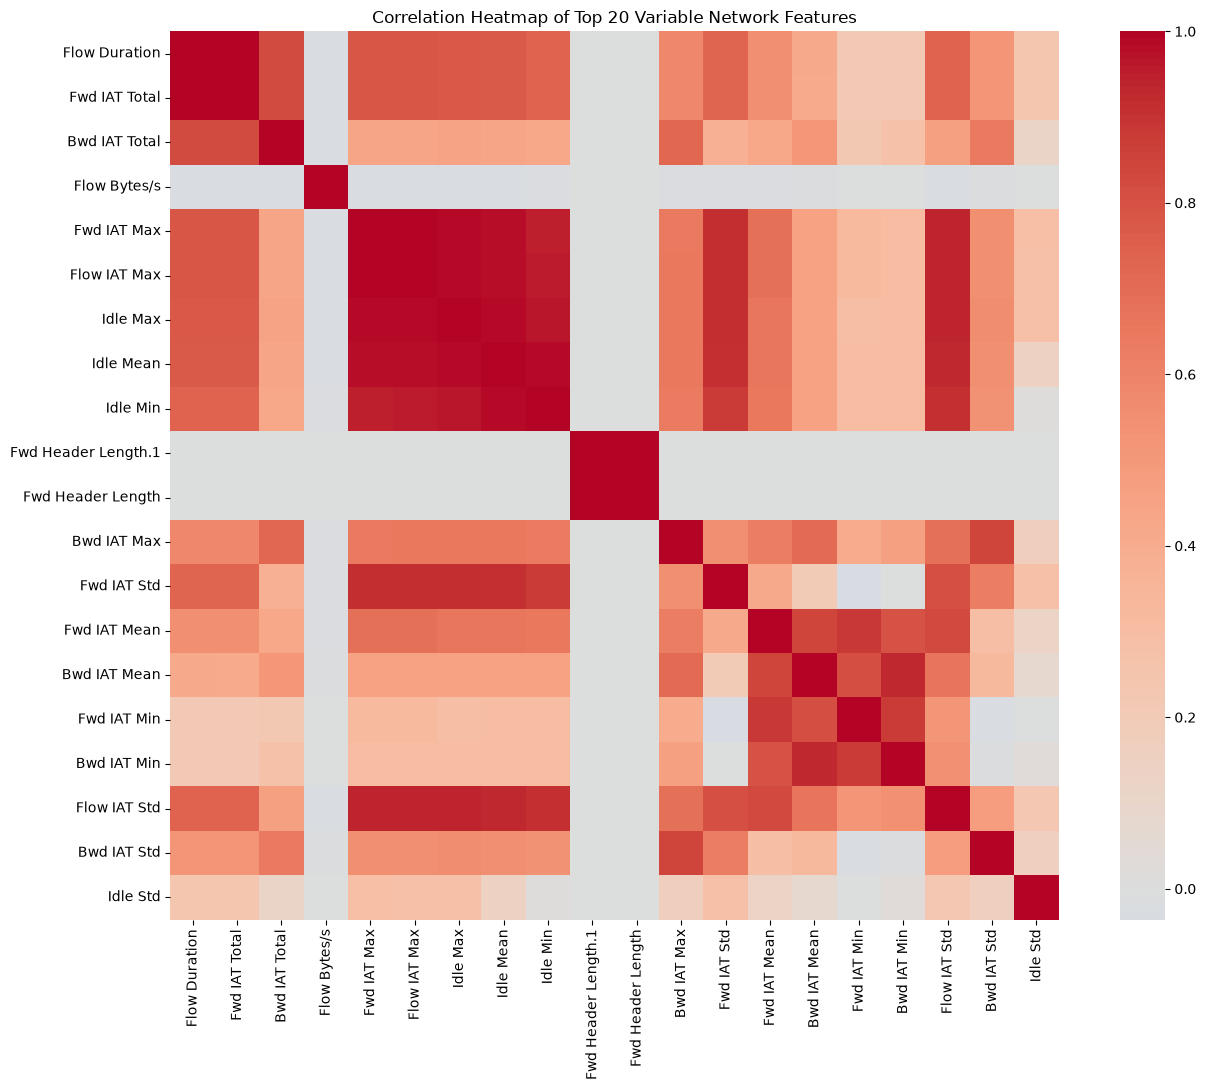

In [18]:
# Correlation heatmap of the 20 most variable network features

feature_variance = corr_sample.var().sort_values(ascending=False)

top_features = feature_variance.head(20).index

heatmap_data = corr_sample[top_features]

plt.figure(figsize=(14, 11))

sns.heatmap(
    heatmap_data.corr(),
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Heatmap of Top 20 Variable Network Features")
plt.tight_layout()

plt.savefig(
    "../results/graphs/correlation_heatmap_top20.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
# Create an overall EDA summary report

eda_summary = pd.DataFrame({
    "Metric": [
        "Total network flows",
        "Total network features",
        "Number of attack families",
        "Missing values",
        "Infinite values",
        "Constant features",
        "Highly correlated feature pairs",
        "Rare classes (<100 samples)"
    ],
    "Value": [
        len(labels),
        78,
        labels["Attack_Type"].nunique(),
        int(missing_counts.sum()),
        int(infinite_counts.sum()),
        len(constant_features),
        len(correlation_report),
        len(rare_class_report)
    ]
})

print("EDA Summary:")
print(eda_summary.to_string(index=False))

eda_summary.to_csv(
    "../results/reports/eda_summary.csv",
    index=False
)

print("\nSaved:")
print("../results/reports/eda_summary.csv")

EDA Summary:
                         Metric   Value
            Total network flows 2827876
         Total network features      78
      Number of attack families       9
                 Missing values       0
                Infinite values       0
              Constant features       8
Highly correlated feature pairs      39
    Rare classes (<100 samples)       2

Saved:
../results/reports/eda_summary.csv
